In [1]:
import sympy as sp
from sympy.combinatorics import permutations
import itertools
from dataclasses import dataclass
from typing import Literal
import torch
import torch.nn as nn
import numpy as np
from spin_lattices import TriangleLattice, SquareLattice1Diag
from heisenberg_hamiltonians import HeisenbergJ1J2
from typing import Iterable
import numpy.typing as npt
from math import factorial
from random import shuffle


2023-04-07 21:54:55.664 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-04-07 21:54:55.667 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [2023-04-07 21:54:55.694 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


In [2]:
@dataclass
class FermionOperator:
    index: int
    spin: str
    dagger: bool = True

    def __init__(self, index, spin, dagger=True):
        if spin not in ["up", "down", "↑", "↓"]:
            raise ValueError('spin must be "up" or "down"')
        self.index = index
        self.spin = {"up": "↑", "down": "↓"}.get(spin, spin)
        self.dagger = dagger

    def __str__(self):
        if self.dagger:
            dagger = "^\\dagger"
        else:
            dagger = ""
        return f"c{dagger}_{{{self.index}{self.spin}}}"


In [233]:
configuration = "↑↑↑↑↓↓↓↓"
term = [FermionOperator(i, spin) for i, spin in enumerate(configuration)]
assert configuration.count("↑") == configuration.count("↓")


In [234]:
def f(i: int, j: int):
    return sp.Symbol(f"f_{{{i}{j}}}")


In [297]:
def mk_expression(configuration):
    assert configuration.count("↑") == configuration.count("↓")

    term = [FermionOperator(i, spin) for i, spin in enumerate(configuration)]
    expression = sp.sympify(0)
    idx_up = [i for i, c in enumerate(term) if c.spin == "↑"]
    idx_down = [i for i, c in enumerate(term) if c.spin == "↓"]
    assert len(idx_up) == len(idx_down)
    perm_initial = list(itertools.chain(*zip(idx_up, idx_down)))
    sign_correction = permutations.Permutation(perm_initial).signature()
    for perm_up in itertools.permutations(range(len(idx_up))):
        for perm_down in itertools.permutations(range(len(idx_down))):
            new_term = []
            for i in range(len(idx_up)):
                new_term.append(FermionOperator(idx_up[perm_up[i]], "↑"))
                new_term.append(FermionOperator(idx_down[perm_down[i]], "↓"))
            permutation = [c.index for c in new_term]
            sign = permutations.Permutation(permutation).signature()
            expr_term = sign
            for ci, cj in zip(new_term[::2], new_term[1::2]):
                expr_term *= f(ci.index, cj.index)
            expression += expr_term
    m = sp.Matrix([[f(j, i) for j in idx_up] for i in idx_down])
    return expression, m.det() * sign_correction


In [249]:
for m in range(1, 5):
    print(f"{m=}")
    configuration = list("↑" * m + "↓" * m)
    for i in range(1000):
        if i % 100 == 0:
            print(f"{''.join(configuration)}")
        shuffle(configuration)
        expression, det = mk_expression("".join(configuration))
        assert sp.simplify(expression / det) == factorial(m)


m=1
↑↓
↑↓
↓↑
↓↑
↓↑
↑↓
↑↓
↑↓
↑↓
↓↑
m=2
↑↑↓↓
↓↑↓↑
↓↑↑↓
↓↓↑↑
↓↓↑↑
↑↑↓↓
↓↑↓↑
↑↑↓↓
↓↑↓↑
↑↓↑↓
m=3
↑↑↑↓↓↓
↓↑↓↑↑↓
↑↑↑↓↓↓
↑↓↓↑↑↓
↓↓↑↑↑↓
↑↓↑↓↑↓
↑↓↓↑↓↑
↓↓↑↑↑↓
↑↓↓↑↑↓
↓↓↑↑↑↓
m=4
↑↑↑↑↓↓↓↓
↑↑↑↓↑↓↓↓
↓↑↓↑↓↑↑↓
↓↓↓↓↑↑↑↑
↑↑↓↑↓↓↓↑
↑↓↓↓↑↑↑↓
↓↓↓↑↑↓↑↑
↓↑↓↑↓↓↑↑
↑↑↓↓↑↓↑↓
↓↓↑↑↑↑↓↓


In [21]:
from determinant_2023_04_07 import SlaterDeterminant

In [305]:
for m in range(1, 5):
    determinant = SlaterDeterminant(m * 2)
    print(f"{m=}")
    configuration = list('↑' * m + '↓' * m)
    for _ in range(10):
        shuffle(configuration)
        conf_tensor = torch.tensor([[i for i, c in enumerate(configuration) if c == '↑'], 
                                    [i for i, c in enumerate(configuration) if c == '↓']])
        torch_det = determinant(conf_tensor).item()
        expr_det = float(mk_expression(configuration)[0].subs(
            {f(i, j): determinant.f[i, j].item() for i in range(m * 2) for j in range(m * 2)}
        ).evalf())
        assert np.isclose(torch_det, expr_det)
            

m=1
m=2
m=3
m=4


In [306]:
configurations = ["↑↑↑↓↓↓", "↑↑↓↑↓↓", "↑↑↑↓↓↓"]


In [309]:
conf_tensors = torch.tensor(
    [
        [
            [i for i, c in enumerate(configuration) if c == "↑"],
            [i for i, c in enumerate(configuration) if c == "↓"],
        ]
        for configuration in configurations
    ]
)


In [311]:
det = SlaterDeterminant(6)
print(det(conf_tensors))
for conf_tensor in conf_tensors:
    print(det(conf_tensor))

tensor([-3.6422, -0.5491, -3.6422], grad_fn=<MulBackward0>)
tensor(-3.6422, grad_fn=<MulBackward0>)
tensor(-0.5491, grad_fn=<MulBackward0>)
tensor(-3.6422, grad_fn=<MulBackward0>)


In [108]:
lattice = SquareLattice1Diag(2, 3, boundary_conditions="open")
system = HeisenbergJ1J2(lattice, J1=1, J2=1, use_symmetries=False, spin_inversion=None)

2023-04-06 15:05:47.525 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=12
2023-04-06 15:05:47.531 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 0 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-06 15:05:47.544 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 924


<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

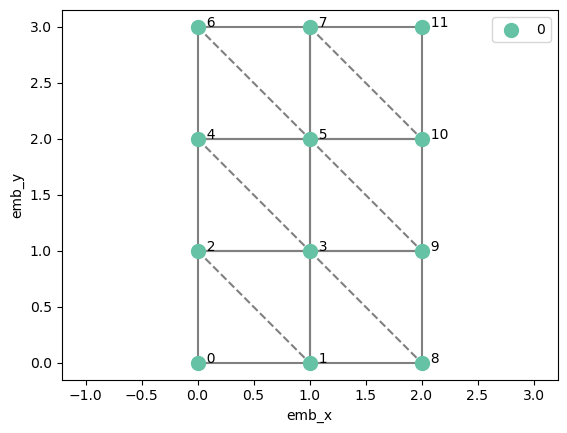

In [109]:
lattice.plot()

In [110]:
system.get_eigenstates(1)

2023-04-06 15:05:52.395 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:94 - Calculating eigenvalues / eigenstates
2023-04-06 15:05:54.113 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -22.6906469356


(array([-22.69064694]),
 array([[ 1.10802073e-03],
        [ 8.34663317e-04],
        [-4.59668986e-03],
        [-1.06932891e-03],
        [ 8.17184450e-03],
        [-8.94437328e-04],
        [-3.55407246e-03],
        [-2.58942155e-03],
        [ 8.36058174e-03],
        [ 4.30455335e-03],
        [-2.79364567e-02],
        [ 2.41250239e-03],
        [ 1.43402200e-02],
        [-1.07121006e-03],
        [-8.94437328e-04],
        [ 7.20627785e-03],
        [-1.37123495e-03],
        [-2.11463728e-03],
        [-2.64555758e-03],
        [ 1.26519625e-02],
        [ 1.47026917e-03],
        [-1.41693559e-02],
        [-1.95502080e-03],
        [ 8.27719495e-05],
        [ 2.17701932e-03],
        [-1.57965242e-03],
        [ 3.44104510e-03],
        [-1.20218811e-04],
        [-2.36800333e-04],
        [ 1.74190988e-04],
        [ 1.68188057e-03],
        [-1.65599961e-03],
        [-3.92933571e-03],
        [ 2.85804336e-03],
        [ 1.09775800e-03],
        [ 1.10802073e-03],
    

In [111]:
def configuration_to_tensor(configuration: Iterable, up=1, down=0):
    return torch.tensor(
        [
            [i for i, c in enumerate(configuration) if c == up],
            [i for i, c in enumerate(configuration) if c == down],
        ]
    )

In [112]:
def sign_overlap(true: npt.NDArray[np.float64], pred: npt.NDArray[np.float64]) -> float:
    probs = np.abs(true) ** 2
    return float(np.sum((np.sign(true) * np.sign(pred)) * probs) / np.sum(probs))

In [113]:
system.number_spins

12

In [114]:
determinant = SlaterDeterminant(system.number_spins)

In [115]:
ground_state = system.get_df_ground_state(canonical_basis=True, unpack_configurations=True)
configurations_tensor = torch.stack(list(ground_state.configuration.apply(configuration_to_tensor).values))
ground_state_coeffs = ground_state['eigenstate_coeff'].values.astype('float64')

In [116]:
ground_state_coeffs

array([ 1.10802073e-03,  8.34663317e-04, -4.59668986e-03, -1.06932891e-03,
        8.17184450e-03, -8.94437328e-04, -3.55407246e-03, -2.58942155e-03,
        8.36058174e-03,  4.30455335e-03, -2.79364567e-02,  2.41250239e-03,
        1.43402200e-02, -1.07121006e-03, -8.94437328e-04,  7.20627785e-03,
       -1.37123495e-03, -2.11463728e-03, -2.64555758e-03,  1.26519625e-02,
        1.47026917e-03, -1.41693559e-02, -1.95502080e-03,  8.27719495e-05,
        2.17701932e-03, -1.57965242e-03,  3.44104510e-03, -1.20218811e-04,
       -2.36800333e-04,  1.74190988e-04,  1.68188057e-03, -1.65599961e-03,
       -3.92933571e-03,  2.85804336e-03,  1.09775800e-03,  1.10802073e-03,
       -3.40809500e-03, -2.58942155e-03,  3.19387483e-03, -5.53968594e-03,
        1.67159660e-04,  1.62207774e-02, -7.52351027e-03,  9.90059463e-03,
        4.30455335e-03, -1.03860344e-02, -2.08496697e-02,  7.67416548e-03,
        7.73753348e-03, -2.40015866e-03, -3.92933571e-03,  1.28567088e-02,
        7.64812673e-03, -

In [117]:
determinant(configurations_tensor)

tensor([-6.8618e+03,  1.6471e+03,  1.3467e+04,  2.8025e+02,  1.9986e+04,
        -1.5490e+03,  5.0944e+02,  2.3482e+04, -8.7595e+02,  2.7501e+02,
        -2.8540e+03,  1.1236e+04, -1.4536e+04, -4.2042e+04,  3.7759e+03,
        -1.6561e+04, -6.0796e+03, -2.1534e+04, -5.9038e+02,  1.2318e+04,
        -3.5068e+04,  3.4005e+04, -1.0517e+03,  1.4857e+03,  2.7560e+03,
        -2.1966e+03,  7.3578e+04, -4.7417e+04, -8.2372e+03, -5.6291e+03,
        -1.2834e+03, -7.1823e+03,  7.5088e+02,  1.0640e+04, -1.2999e+03,
        -6.4426e+02,  6.2882e+03, -5.6588e+03,  9.8991e+03,  6.9896e+02,
         2.4349e+02, -7.3061e+03, -1.8224e+04,  3.7342e+02, -1.7373e+02,
         1.7149e+03, -9.6621e+03, -1.7288e+04,  2.7591e+03,  1.3171e+03,
        -5.7335e+02, -1.1545e+04,  7.1370e+03, -1.7282e+03, -1.3576e+02,
        -4.4662e+03,  3.7396e+03, -1.4518e+04, -1.3587e+02,  9.0646e+02,
        -6.8403e+02,  4.3266e+03, -3.1130e+03, -3.1970e+03, -3.0959e+03,
         3.2526e+04, -1.2795e+04, -1.4614e+04,  1.5

In [118]:
@torch.no_grad()
def loss(f):
    determinant.f = nn.Parameter(torch.tensor(f.reshape(system.number_spins, system.number_spins)))
    return -sign_overlap(ground_state_coeffs, determinant(configurations_tensor).numpy())

In [119]:
from scipy.optimize import dual_annealing

In [120]:
anneal_res = dual_annealing(loss, bounds=[(-10., 10.)] * system.number_spins ** 2)

In [ ]:
anneal_res

array([-6.35913759, -6.04709296,  9.29131758, -2.80002166,  7.07229927,
       -4.08574092, -6.57461561,  0.92961418,  6.23209938,  1.61781527,
       -3.51639465, -2.28584474,  6.93019109,  0.87645429,  9.64117335,
        3.18071815, -0.71545326, -3.34813462, -1.11253569,  7.05227325,
        2.99971452, -3.97271044, -6.22604478,  6.5197657 , -9.38042515,
       -6.47853771,  4.58465603,  6.5303171 , -4.10069432,  9.79366615,
       -9.527788  ,  4.09127251,  7.90042486, -1.21257831,  4.09756429,
       -4.04436238])

In [85]:
determinant.f = nn.Parameter(torch.tensor(anneal_res.x.reshape(system.number_spins, system.number_spins)))

In [86]:
determinant(configurations_tensor)

tensor([  494.8006, -3393.9877,   308.7653,  2483.7121, -2101.0620, -2789.1978,
         3475.1959,  7455.4988, -2175.1843, -2890.1881,   164.5619,   929.1865,
        -1151.4762, -3418.1752,   454.1957,  2327.7729, -4300.1027,  -792.7322,
         3081.7122,   -47.3271], dtype=torch.float64, grad_fn=<MulBackward0>)

In [87]:
ground_state_coeffs

array([ 0.05789794, -0.21017545,  0.01984547,  0.13243204, -0.11828888,
       -0.21017545,  0.27056639,  0.46089636, -0.13243204, -0.27056639,
        0.27056639,  0.13243204, -0.46089636, -0.27056639,  0.21017545,
        0.11828888, -0.13243204, -0.01984547,  0.21017545, -0.05789794])

In [91]:
(np.sign(determinant(configurations_tensor).detach().numpy()) == np.sign(ground_state_coeffs)).all()

True

In [2]:
from determinant_2023_04_07 import *

2023-04-07 21:55:01.934 | DEBUG    | determinant_2023_04_07:<module>:26 - Lattice: SquareLattice1Diag2x3open, lattice.number_spins=12
2023-04-07 21:55:01.935 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=12
2023-04-07 21:55:01.937 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 0 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-07 21:55:01.961 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 924
2023-04-07 21:55:01.968 | DEBUG    | determinant_2023_04_07:<module>:28 - System: HeisenbergJ1J2-SquareLattice1Diag2x3open-1.0-1.0-False-None


In [3]:
list(output_dir.glob("*"))

[PosixPath('experiments/determinant_2023_04_07/anneal_res_HeisenbergJ1J2-SquareLattice1Diag2x1open-1.0-1.0-False-None.pkl'),
 PosixPath('experiments/determinant_2023_04_07/anneal_res_HeisenbergJ1J2-SquareLattice1Diag2x3open-1.0-1.0-False-None.pkl')]

In [5]:
anneal_res = pickle.loads(Path("experiments/determinant_2023_04_07/anneal_res_HeisenbergJ1J2-SquareLattice1Diag2x3open-1.0-1.0-False-None.pkl").read_bytes())

In [7]:
anneal_res.x.shape

(144,)

In [9]:
determinant = SlaterDeterminant(system.number_spins)
determinant.f = nn.Parameter(torch.tensor(anneal_res.x.reshape(system.number_spins, system.number_spins)))

In [12]:
system.get_eigenstates(1);

In [13]:
ground_state = system.get_df_ground_state(canonical_basis=True, unpack_configurations=True)
configurations_tensor = torch.stack(list(ground_state.configuration.apply(configuration_to_tensor).values))
ground_state_coeffs = ground_state['eigenstate_coeff'].values.astype('float64')

In [26]:
%%timeit
determinant.f = nn.Parameter(torch.randn(system.number_spins, system.number_spins))
determinant(configurations_tensor)

79.3 ms ± 1.99 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [31]:
f_ = nn.Parameter(torch.randn(system.number_spins, system.number_spins))
torch.linalg.det(f_[::2, ::2])

tensor(1.5529, grad_fn=<LinalgDetBackward0>)

In [33]:
f_[::2, ::2].shape

torch.Size([6, 6])

In [19]:
(torch.sign(determinant(configurations_tensor)).detach().numpy() == np.sign(ground_state_coeffs)).mean()

0.9231601731601732

In [34]:
%%timeit
x = configurations_tensor
signs = []
for i in range(x.shape[0]):
    perm_initial = list(itertools.chain(*zip(x[i, 0, :], x[i, 1, :])))
    signs.append(permutations.Permutation(perm_initial).signature())

70.3 ms ± 870 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [20]:
anneal_res

 message: ['Maximum number of iteration reached']
 success: True
  status: 0
     fun: -0.998935870628339
       x: [ 3.800e+00 -6.831e+00 ...  8.787e+00 -9.065e+00]
     nit: 1000
    nfev: 304676
    njev: 115
    nhev: 0

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

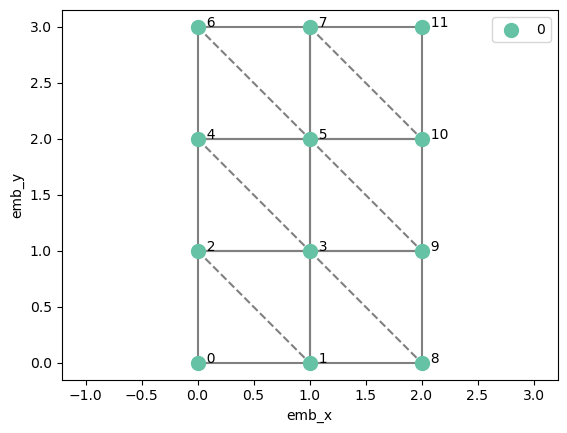

In [21]:
system.lattice.plot()